# Why the planner leaves the road

VOPP survives only **6 of 30 episodes** on this environment. Every failure is off-road;
there are no collisions. Raising the search budget does nothing: 8, 11 and 14 planning
iterations all give exactly 20% survival while median decision time triples.

That pattern &mdash; more search, identical outcome &mdash; says the planner is not
search-limited. This notebook finds what it *is* limited by. There turn out to be two
causes, both in the environment's design rather than in VOPP, and both measurable.

Nothing here is asserted; every claim is computed in the cell above it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from POMDPPlanners.environments.racetrack_pomdp import (
    DEFAULT_ACTION_PRESETS,
    ObservationMode,
    RacetrackModelPOMDP,
    RacetrackPOMDP,
)
from POMDPPlanners.environments.racetrack_pomdp.racetrack_schema import (
    EGO_CURVATURE,
    EGO_LAT,
)

COAST_STRAIGHT = 4  # index of the (0.0, 0.0) preset
LANE_HALF_WIDTH_M = 2.5


def fresh_world(seed=0, **kwargs):
    world = RacetrackPOMDP(
        discount_factor=0.95, observation_mode=ObservationMode.POMDP, seed=seed, **kwargs
    )
    return world, world.initial_state_dist().sample()[0]


def noise_free_model():
    return RacetrackModelPOMDP(
        discount_factor=0.95, observation_mode=ObservationMode.POMDP,
        max_tracked_agents=4, process_noise_std=0.0,
    )

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25})

# POMDPPlanners selects the Agg backend on import; re-select inline so figures render here.
%matplotlib inline


## The symptom: it always runs out of road, never into a car

First, reproduce the failure without any planner at all. Coast straight from the start and
watch the lateral offset from the lane centreline.

2026-08-10 10:29:10,791 - INFO: /home/kobi/Documents/github/POMDPPlanners-racetrack/POMDPPlanners/core/environment/environment.py:188 - Initializing RacetrackPOMDP-pomdp environment with discount factor 0.95


/home/kobi/Documents/github/POMDPPlanners/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment racetrack-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


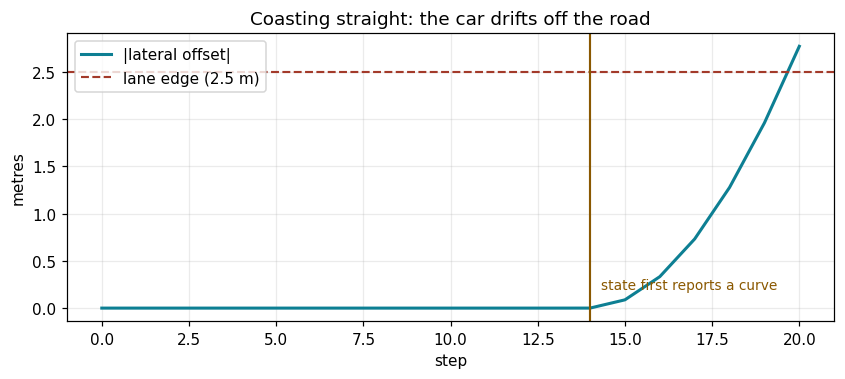

left the road after 21 steps
state first reports non-zero curvature at step 14


In [2]:
world, state = fresh_world()
lat_trace, curv_trace = [], []
for _ in range(40):
    state = world.sample_next_state(state, COAST_STRAIGHT)
    lat_trace.append(float(state[EGO_LAT]))
    curv_trace.append(float(state[EGO_CURVATURE]))
    if world.is_terminal(state):
        break

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(np.abs(lat_trace), color='#0d7f93', lw=2, label='|lateral offset|')
ax.axhline(LANE_HALF_WIDTH_M, color='#a33a2a', ls='--', lw=1.4, label='lane edge (2.5 m)')
curv = np.array(curv_trace)
first_curve = int(np.argmax(np.abs(curv) > 1e-9)) if np.any(np.abs(curv) > 1e-9) else None
if first_curve is not None:
    ax.axvline(first_curve, color='#8a5800', lw=1.4)
    ax.text(first_curve + 0.3, 0.2, 'state first reports a curve', color='#8a5800', fontsize=9)
ax.set_xlabel('step'); ax.set_ylabel('metres'); ax.legend(loc='upper left')
ax.set_title('Coasting straight: the car drifts off the road')
plt.show()

print(f'left the road after {len(lat_trace)} steps')
print(f'state first reports non-zero curvature at step {first_curve}')

The car leaves the road, and notice **when** the state first admits there is a curve. The
drift is already under way by then. That is the first clue.

## Cause 1: the state has no lookahead, so the model cannot see the corner

The ego state carries `curvature` &mdash; but only of the lane it is **currently on**. On the
straight approaching a bend that value is exactly `0.0`, and the planner's model holds it
fixed for the whole rollout. So every rollout assumes the road stays straight.

Below: at each step on the approach, ask the model to predict 6 steps of coasting, and
compare its predicted lateral offset against what the world actually does 6 steps later.

2026-08-10 10:29:11,284 - INFO: /home/kobi/Documents/github/POMDPPlanners-racetrack/POMDPPlanners/core/environment/environment.py:188 - Initializing RacetrackPOMDP-pomdp environment with discount factor 0.95


2026-08-10 10:29:11,306 - INFO: /home/kobi/Documents/github/POMDPPlanners-racetrack/POMDPPlanners/core/environment/environment.py:188 - Initializing RacetrackModelPOMDP-pomdp environment with discount factor 0.95


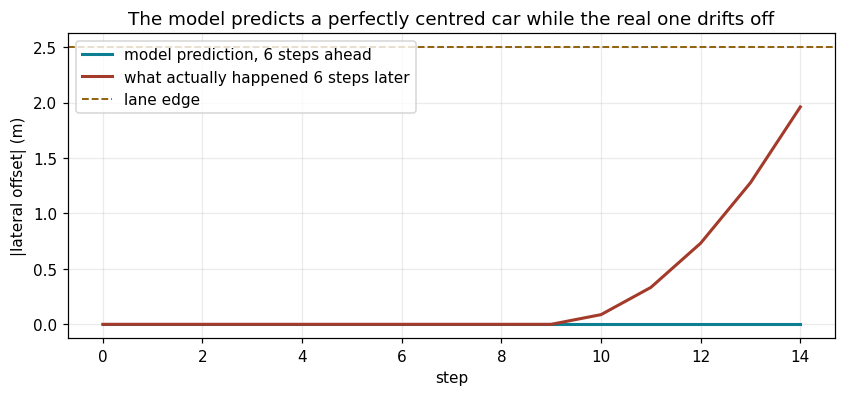

 step  curvature  predicted   actual    error
    0     0.0000      0.000    0.000    0.000
    1     0.0000      0.000    0.000    0.000
    2     0.0000      0.000    0.000    0.000
    3     0.0000      0.000    0.000    0.000
    4     0.0000      0.000    0.000    0.000
    5     0.0000      0.000    0.000    0.000
    6     0.0000      0.000    0.000    0.000
    7     0.0000      0.000    0.000    0.000
    8     0.0000      0.000    0.000    0.000
    9     0.0000      0.000    0.000    0.000
   10     0.0000      0.000    0.088    0.088
   11     0.0000      0.000    0.333    0.333
   12     0.0000      0.000    0.732    0.732
   13     0.0000      0.000    1.277    1.277
   14     0.0000      0.000    1.961    1.961


In [3]:
world, state = fresh_world()
model = noise_free_model()
HORIZON = 6

records = []
for _ in range(24):
    rollout = np.array(state, dtype=float)
    for _ in range(HORIZON):
        rollout = model.sample_next_state(rollout, COAST_STRAIGHT)
    records.append({'curvature': float(state[EGO_CURVATURE]),
                    'lat': float(state[EGO_LAT]),
                    'predicted': float(rollout[EGO_LAT])})
    state = world.sample_next_state(state, COAST_STRAIGHT)
    if world.is_terminal(state):
        break

steps = range(len(records) - HORIZON)
predicted = [records[i]['predicted'] for i in steps]
actual = [records[i + HORIZON]['lat'] for i in steps]

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(list(steps), np.abs(predicted), color='#0d7f93', lw=2,
        label=f'model prediction, {HORIZON} steps ahead')
ax.plot(list(steps), np.abs(actual), color='#a33a2a', lw=2,
        label=f'what actually happened {HORIZON} steps later')
ax.axhline(LANE_HALF_WIDTH_M, color='#8a5800', ls='--', lw=1.2, label='lane edge')
ax.set_xlabel('step'); ax.set_ylabel('|lateral offset| (m)')
ax.set_title('The model predicts a perfectly centred car while the real one drifts off')
ax.legend(loc='upper left')
plt.show()

print(f'{"step":>5} {"curvature":>10} {"predicted":>10} {"actual":>8} {"error":>8}')
for i in steps:
    print(f'{i:>5} {records[i]["curvature"]:>10.4f} {predicted[i]:>10.3f} '
          f'{actual[i]:>8.3f} {abs(predicted[i] - actual[i]):>8.3f}')

The blue line never leaves zero. The model is not merely inaccurate about the corner &mdash;
it is **structurally unable to represent one**, because the only geometry in its state is a
single scalar that reads `0.0` on a straight.

### It is worse than blindness: the model thinks steering is harmful

If the road is straight forever, then any steering moves you off centre and costs control
effort. So the model does not merely miss the corner &mdash; it ranks the one manoeuvre that
would survive it as the *worst* thing available.

2026-08-10 10:29:11,627 - INFO: /home/kobi/Documents/github/POMDPPlanners-racetrack/POMDPPlanners/core/environment/environment.py:188 - Initializing RacetrackPOMDP-pomdp environment with discount factor 0.95


2026-08-10 10:29:11,768 - INFO: /home/kobi/Documents/github/POMDPPlanners-racetrack/POMDPPlanners/core/environment/environment.py:188 - Initializing RacetrackModelPOMDP-pomdp environment with discount factor 0.95


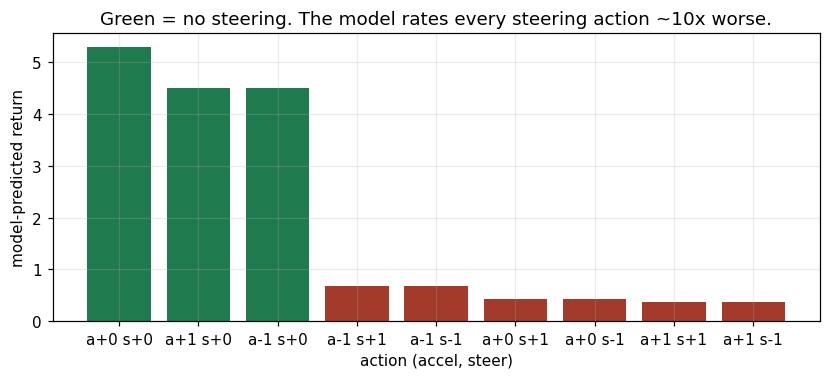

model prefers a+0 s+0 with return 5.298
best steering action scores 0.673


In [4]:
world, state = fresh_world()
for _ in range(12):  # park on the straight, just before the bend bites
    state = world.sample_next_state(state, COAST_STRAIGHT)
model = noise_free_model()

labels, returns, final_lat = [], [], []
for action, (accel, steer) in enumerate(DEFAULT_ACTION_PRESETS):
    rollout = np.array(state, dtype=float)
    total, discount = 0.0, 1.0
    for _ in range(HORIZON):
        nxt = model.sample_next_state(rollout, action)
        total += discount * model.reward(rollout, action, nxt)
        discount *= 0.95
        rollout = nxt
    labels.append(f'a{accel:+.0f} s{steer:+.0f}')
    returns.append(total)
    final_lat.append(float(rollout[EGO_LAT]))

order = np.argsort(returns)[::-1]
colours = ['#1f7a4d' if abs(DEFAULT_ACTION_PRESETS[i][1]) < 1e-9 else '#a33a2a' for i in order]
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar([labels[i] for i in order], [returns[i] for i in order], color=colours)
ax.set_ylabel('model-predicted return'); ax.set_xlabel('action (accel, steer)')
ax.set_title('Green = no steering. The model rates every steering action ~10x worse.')
plt.show()

best = int(np.argmax(returns))
print(f'model prefers {labels[best]} with return {returns[best]:.3f}')
print(f'best steering action scores {max(r for i, r in enumerate(returns) if abs(DEFAULT_ACTION_PRESETS[i][1]) > 0):.3f}')

**This is why more search cannot help.** Every branch of the tree inherits the same wrong
geometry, so a deeper or wider search only explores a more thorough version of the wrong
model. It matches the observation that 8, 11 and 14 planning iterations all produced
exactly 20% survival while median decision time went from 0.36 s to 0.85 s.

## Cause 2: the action set is bang-bang

The shipped presets offer only `{-1, 0, +1}` steering, and `±1` is the full `±pi/4` lock.
There is no gentle corrective steer. Sweep constant steering values through the curve and
see how long each survives.

2026-08-10 10:29:11,901 - INFO: /home/kobi/Documents/github/POMDPPlanners-racetrack/POMDPPlanners/core/environment/environment.py:188 - Initializing RacetrackPOMDP-pomdp environment with discount factor 0.95


2026-08-10 10:29:11,974 - INFO: /home/kobi/Documents/github/POMDPPlanners-racetrack/POMDPPlanners/core/environment/environment.py:188 - Initializing RacetrackPOMDP-pomdp environment with discount factor 0.95


2026-08-10 10:29:12,065 - INFO: /home/kobi/Documents/github/POMDPPlanners-racetrack/POMDPPlanners/core/environment/environment.py:188 - Initializing RacetrackPOMDP-pomdp environment with discount factor 0.95


2026-08-10 10:29:12,179 - INFO: /home/kobi/Documents/github/POMDPPlanners-racetrack/POMDPPlanners/core/environment/environment.py:188 - Initializing RacetrackPOMDP-pomdp environment with discount factor 0.95


2026-08-10 10:29:12,319 - INFO: /home/kobi/Documents/github/POMDPPlanners-racetrack/POMDPPlanners/core/environment/environment.py:188 - Initializing RacetrackPOMDP-pomdp environment with discount factor 0.95


...

2026-08-10 10:29:12,648 - INFO: /home/kobi/Documents/github/POMDPPlanners-racetrack/POMDPPlanners/core/environment/environment.py:188 - Initializing RacetrackPOMDP-pomdp environment with discount factor 0.95


2026-08-10 10:29:12,963 - INFO: /home/kobi/Documents/github/POMDPPlanners-racetrack/POMDPPlanners/core/environment/environment.py:188 - Initializing RacetrackPOMDP-pomdp environment with discount factor 0.95


2026-08-10 10:29:13,199 - INFO: /home/kobi/Documents/github/POMDPPlanners-racetrack/POMDPPlanners/core/environment/environment.py:188 - Initializing RacetrackPOMDP-pomdp environment with discount factor 0.95


2026-08-10 10:29:13,342 - INFO: /home/kobi/Documents/github/POMDPPlanners-racetrack/POMDPPlanners/core/environment/environment.py:188 - Initializing RacetrackPOMDP-pomdp environment with discount factor 0.95


2026-08-10 10:29:13,444 - INFO: /home/kobi/Documents/github/POMDPPlanners-racetrack/POMDPPlanners/core/environment/environment.py:188 - Initializing RacetrackPOMDP-pomdp environment with discount factor 0.95


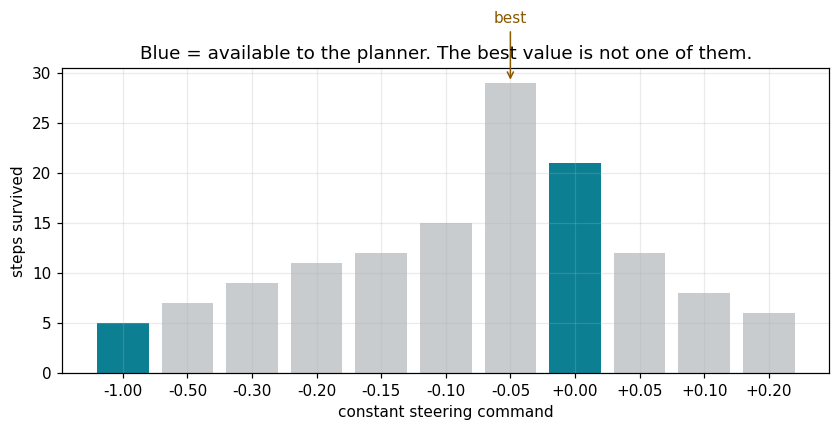

best constant steer -0.05 survives 29 steps
planner can only choose from [-1.0, 0.0, 1.0]


In [5]:
sweep = [-1.0, -0.5, -0.3, -0.2, -0.15, -0.1, -0.05, 0.0, 0.05, 0.1, 0.2]
survived = []
for steer in sweep:
    world, state = fresh_world(action_presets=((0.0, steer),))
    steps_taken = 0
    for step in range(80):
        state = world.sample_next_state(state, 0)
        steps_taken = step + 1
        if world.is_terminal(state):
            break
    survived.append(steps_taken)

available = {p[1] for p in DEFAULT_ACTION_PRESETS}
colours = ['#0d7f93' if s in available else '#c9ccce' for s in sweep]
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar([f'{s:+.2f}' for s in sweep], survived, color=colours)
best = int(np.argmax(survived))
ax.annotate('best', xy=(best, survived[best]), xytext=(best, survived[best] + 6),
            ha='center', color='#8a5800',
            arrowprops=dict(arrowstyle='->', color='#8a5800'))
ax.set_xlabel('constant steering command'); ax.set_ylabel('steps survived')
ax.set_title('Blue = available to the planner. The best value is not one of them.')
plt.show()

print(f'best constant steer {sweep[best]:+.2f} survives {survived[best]} steps')
print(f'planner can only choose from {sorted(available)}')

The best constant steering value is **20x finer** than the smallest non-zero command the
planner can select. Even a planner that saw the corner perfectly could not track it: the
manoeuvre the track needs is not in its vocabulary.

A constant steer cannot follow a circuit of straights and arcs, so this is not a solution
&mdash; it is a diagnostic. It shows the action discretisation is a *separate*, independent
limit from the missing lookahead.

## Conclusion, and what to change

Neither cause is about VOPP. The 20% survival figure measures this environment's model
fidelity, not the planner's quality. Two fixes, cheapest first:

1. **Add intermediate steering presets** (`±0.05`, `±0.1`, `±0.25`). A one-line change to
   `DEFAULT_ACTION_PRESETS`, and the sweep above suggests it should matter.
2. **Put lookahead curvature in the state** &mdash; curvature sampled at, say, 10 m and 20 m
   ahead along the centreline. This is a schema change and the real fix; without it the
   model is structurally unable to anticipate a corner, whatever the action set.

One caveat on interpretation: this run says nothing about partial observability. There were
zero collisions and an opponent is inside the observation window on only ~15% of steps, so
the occupancy grid was almost certainly irrelevant to every decision here. What is being
measured is curve-following.